# 02. Customer Behavioral Feature Matrix Analysis

## Project Overview

This notebook analyzes the **customer-level behavioral feature matrix** derived from transaction-level e-commerce data.

The raw transaction history is transformed into customer-level purchasing, frequency, product-diversity, temporal, and cancellation-related features. These features will serve as the foundation for the project's downstream tasks:

* **Customer segmentation** using unsupervised learning techniques such as K-Means and other clustering algorithms.
* **Behavioral anomaly detection** to identify customers with unusual purchasing patterns.

The analysis in this notebook focuses on understanding the **distribution, relationships, redundancy, and extreme values** within the engineered features before applying preprocessing, dimensionality reduction, and clustering.


### Environment Setup and Project Modules

Import the libraries required for exploratory analysis and load the reusable project modules responsible for:

* Loading the raw transaction data.
* Cleaning transaction records.
* Constructing customer-level behavioral features.

Keeping these operations inside the `src` package ensures that the notebook remains focused on **analysis and experimentation**, while the underlying data-processing logic remains reusable and consistent across the project.


In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

sns.set_theme(style="whitegrid")

from src.data_loader import load_raw_data
from src.cleaning import clean_raw_data
from src.feature_engineering import build_behavioral_features

### Build the Customer Behavioral Feature Matrix

Load the raw transaction data, apply the project’s cleaning pipeline, and construct **customer-level behavioral features** from the cleaned transactions and canceled records.

Each row in customer_df represents one customer, while each column represents a behavioral characteristic derived from that customer's transaction history.

The inspection below verifies the feature matrix dimensions, data types, a sample of customer-level records, and a quick summary before proceeding to feature analysis.

In [2]:
raw_df = load_raw_data('../data/raw/online_retail_II.csv')

df_clean, canceled_df = clean_raw_data(raw_df)

customer_df = build_behavioral_features(df_clean, canceled_df)
print(f'Customer Feature Matrix Shape: {customer_df.shape}')
print('-' * 50, '\n')
customer_df.info()
customer_df.sample(5, random_state=42)

Customer Feature Matrix Shape: (5878, 12)
-------------------------------------------------- 

<class 'pandas.DataFrame'>
RangeIndex: 5878 entries, 0 to 5877
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer ID           5878 non-null   str    
 1   Monetary              5878 non-null   float64
 2   Frequency             5878 non-null   int64  
 3   TotalItemsPurchased   5878 non-null   int64  
 4   UniqueProducts        5878 non-null   int64  
 5   Recency               5878 non-null   float64
 6   CustomerLifetime      5878 non-null   float64
 7   AverageOrderValue     5878 non-null   float64
 8   AverageItemsPerOrder  5878 non-null   float64
 9   PurchaseRate          5878 non-null   float64
 10  WeekendPurchaseRatio  5878 non-null   float64
 11  CancellationRate      5878 non-null   float64
dtypes: float64(8), int64(3), str(1)
memory usage: 580.6 KB


,Customer ID,Monetary,Frequency,TotalItemsPurchased,UniqueProducts,Recency,CustomerLifetime,AverageOrderValue,AverageItemsPerOrder,PurchaseRate,WeekendPurchaseRatio,CancellationRate
5369,17777,647.56,3,501,141,25.033333,75.893750,215.853333,167.000000,0.026010,0.000000,0.000000
4329,16719,3513.62,14,2356,204,15.140972,711.936111,250.972857,168.285714,0.018234,0.142857,0.176471
199,12546,1161.50,2,633,59,47.028472,31.100694,580.750000,316.500000,0.031152,0.000000,0.333333
5083,17484,209.57,2,339,14,576.881250,47.975000,104.785000,169.500000,0.020419,0.000000,0.000000
4810,17207,292.62,1,233,55,652.737500,0.000000,292.620000,233.000000,0.000000,0.000000,0.000000


In [3]:
customer_df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Monetary,5878.0,2955.90,14440.85,2.95,342.28,867.74,2248.30,580987.04
Frequency,5878.0,6.29,13.01,1.00,1.00,3.00,7.00,398.00
TotalItemsPurchased,5878.0,1788.70,8876.30,1.00,187.00,480.00,1350.00,367193.00
UniqueProducts,5878.0,81.99,116.48,1.00,19.00,45.00,103.00,2550.00
Recency,5878.0,201.85,209.35,1.00,26.05,96.04,380.10,739.12
CustomerLifetime,5878.0,273.39,258.96,0.00,0.00,221.03,511.95,738.10
AverageOrderValue,5878.0,385.18,1214.29,2.95,176.68,279.24,414.90,84236.25
AverageItemsPerOrder,5878.0,247.56,1424.48,1.00,91.00,153.58,256.93,87167.00
PurchaseRate,5878.0,0.03,0.13,0.00,0.00,0.01,0.02,2.69
WeekendPurchaseRatio,5878.0,0.14,0.26,0.00,0.00,0.00,0.17,1.00


### Feature Distribution and Transformation Analysis

Before applying scaling or distance-based clustering algorithms, we examine the **distribution and skewness** of the engineered behavioral features.

Highly skewed variables can cause a small number of extreme customers to have a disproportionate influence on distance calculations. Therefore, we compare the original distributions with their `log1p`-transformed versions.

The analysis focuses on:

* **Skewness** — measures the degree of asymmetry in each feature.
* **Log1p skewness** — evaluates whether a logarithmic transformation reduces right-skewness.
* **Minimum, median, and maximum values** — provide context for feature ranges and extreme observations.
* **Distribution plots** — visually compare the original and transformed feature distributions.

The purpose of this analysis is **not to apply a transformation automatically**, but to identify which features may benefit from one before the preprocessing stage.

Features with strong right-skewness and positive values will be considered for `log1p` transformation, while bounded behavioral ratios will be evaluated separately because their distributions have different characteristics.


In [4]:
feature_cols = [c for c in customer_df.columns if c != 'Customer ID']

skewness_summary = pd.DataFrame({
    'Metric': feature_cols,
    'Raw Skewness': customer_df[feature_cols].skew(),
    'Log1p Skewness': np.log1p(customer_df[feature_cols]).skew(),
    'Min': customer_df[feature_cols].min(),
    'Median': customer_df[feature_cols].median(),
    'Max': customer_df[feature_cols].max()
}).reset_index(drop=True)

skewness_summary

,Metric,Raw Skewness,Log1p Skewness,Min,Median,Max
0,Monetary,25.070190,0.269125,2.95,867.740000,580987.040000
1,Frequency,12.639951,1.001471,1.00,3.000000,398.000000
2,TotalItemsPurchased,21.854844,-0.094975,1.00,480.000000,367193.000000
3,UniqueProducts,6.224360,-0.281116,1.00,45.000000,2550.000000
4,Recency,0.887193,-0.448866,1.00,96.035417,739.121528
5,CustomerLifetime,0.387931,-0.675731,0.00,221.032292,738.101389
6,AverageOrderValue,57.132568,0.063341,2.95,279.242679,84236.250000
7,AverageItemsPerOrder,47.907131,-0.629317,1.00,153.583333,87167.000000
8,PurchaseRate,9.857506,8.159791,0.00,0.008899,2.688574
9,WeekendPurchaseRatio,2.191606,1.880397,0.00,0.000000,1.000000


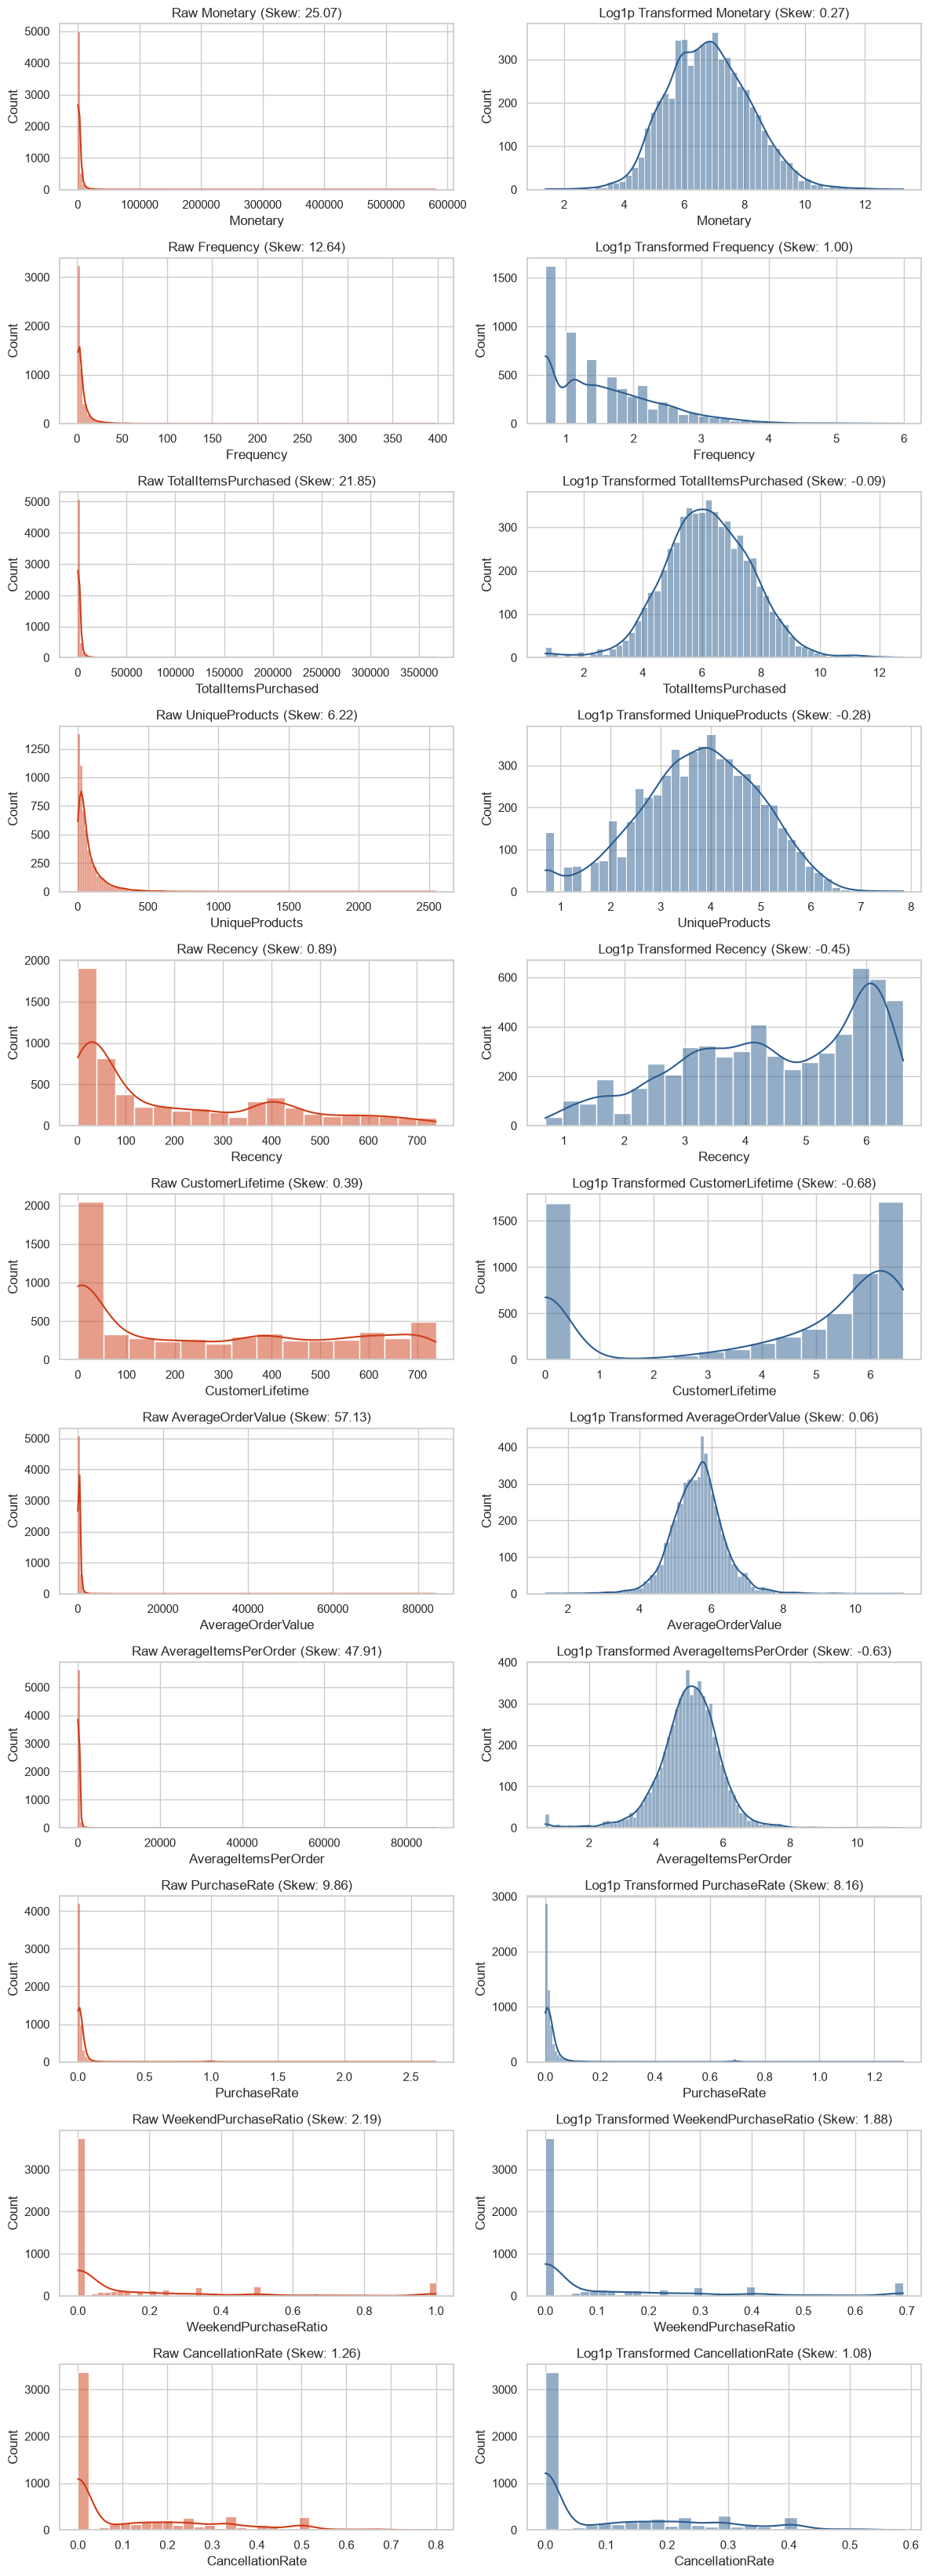

In [5]:
fig, axes = plt.subplots(len(feature_cols), 2, figsize=(12, 3 * len(feature_cols)))

for i, col in enumerate(feature_cols):
    sns.histplot(customer_df[col], kde=True, ax=axes[i, 0], color="#ce3c17")
    axes[i, 0].set_title(f"Raw {col} (Skew: {customer_df[col].skew():.2f})")
    
    sns.histplot(np.log1p(customer_df[col]), kde=True, ax=axes[i, 1], color="#2b5c8f")
    axes[i, 1].set_title(f"Log1p Transformed {col} (Skew: {np.log1p(customer_df[col]).skew():.2f})")

plt.tight_layout()

### Feature Transformation: Addressing Skewness in Purchase Rate

`PurchaseRate` exhibits severe right-skewness that **standard Log1p scaling fails to resolve** due to its small fractional values. To effectively stabilize variance and compress extreme outliers without distorting the underlying behavioral distribution, we apply the parametric **Yeo-Johnson Power Transformation**

In [6]:
pt = PowerTransformer(method='yeo-johnson')

customer_df['PurchaseRate_transformed'] = pt.fit_transform(customer_df[['PurchaseRate']])

print(f"Original Skew: {customer_df['PurchaseRate'].skew():.2f}")
print(f"Transformed Skew: {customer_df['PurchaseRate_transformed'].skew():.2f}")

Original Skew: 9.86
Transformed Skew: 1.06


### Feature Multicollinearity & Correlation Analysis

Before proceeding to feature scaling and clustering, we evaluate **pairwise multicollinearity** among our engineered behavioral features. 

* **Why Spearman Rank Correlation?** Unlike Pearson correlation, Spearman measures monotonic relationships, making it robust against non-linear patterns and residual skewness.
* **Multicollinearity Impact:** Highly collinear feature pairs ($|r| > 0.80$) provide redundant variance information, which can disproportionately weigh certain behavioral dimensions during distance calculation in algorithms like K-Means.

A strong correlation does not automatically mean that a feature should be removed. Features may be correlated while still representing useful and interpretable aspects of customer behavior.

Therefore, the purpose of this analysis is to identify potentially redundant features that should be investigated further before finalizing the modeling feature set.

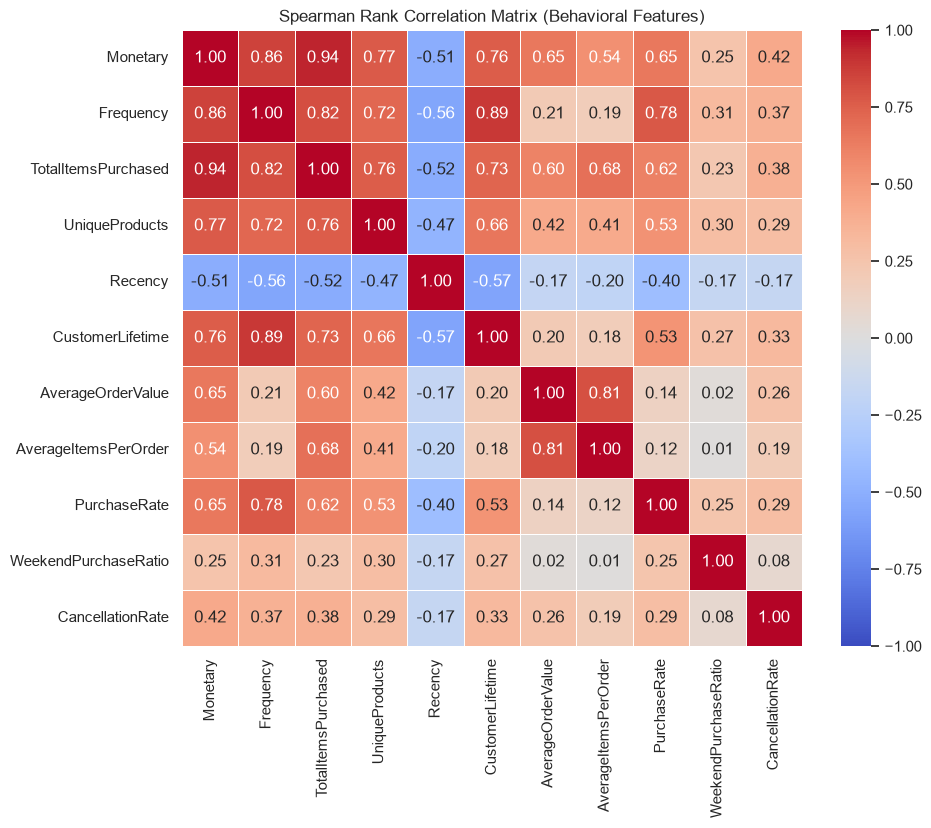

Highly Correlated Feature Pairs (|r| > 0.80):

Monetary  <->  Frequency: 0.8583
Monetary  <->  TotalItemsPurchased: 0.9406
Frequency  <->  TotalItemsPurchased: 0.8202
Frequency  <->  CustomerLifetime: 0.8856
AverageOrderValue  <->  AverageItemsPerOrder: 0.8107


In [7]:
corr_matrix = customer_df[feature_cols].corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, linewidths=0.5)
plt.title("Spearman Rank Correlation Matrix (Behavioral Features)")
plt.show()


mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

threshold = 0.8
high_corr = (
    corr_matrix.where(mask)
    .stack()
    .loc[lambda x: x.abs() > threshold]
)

print(f'Highly Correlated Feature Pairs (|r| > {threshold:.2f}):\n')
for (feat1, feat2), val in high_corr.items():
    print(f'{feat1}  <->  {feat2}: {val:.4f}')

### Statistical Outlier Detection Using the IQR Method

We use the Interquartile Range (IQR) method to identify customers whose values are unusually distant from the central distribution of each behavioral feature.

The purpose of this analysis is to understand the structure of extreme customer behavior, **not to automatically remove these observations.**

In this project, unusually high values for features such as `Monetary`, `Frequency`, or `TotalItemsPurchased` may represent genuine high-engagement or high-value customers. Therefore, an IQR flag alone is not sufficient evidence that a record is erroneous.

The results will instead help us determine an appropriate transformation and scaling strategy for the clustering algorithms.

> **Important: Statistical outlier detection and data-quality validation are different tasks. An observation can be statistically extreme while still being a valid customer.** 

In [8]:
def detect_outliers_iqr(df, columns):
    outlier_counts = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
        outlier_counts[col] = len(outliers)
    return pd.DataFrame.from_dict(outlier_counts, orient='index', columns=['Outlier Count (IQR)'])

outlier_summary = detect_outliers_iqr(customer_df, feature_cols)
outlier_summary['Outlier %'] = (outlier_summary['Outlier Count (IQR)'] / len(customer_df)) * 100

display(outlier_summary.style.format({'Outlier %': '{:.2f}%'}))

,Outlier Count (IQR),Outlier %
Monetary,633,10.77%
Frequency,427,7.26%
TotalItemsPurchased,603,10.26%
UniqueProducts,451,7.67%
Recency,0,0.00%
CustomerLifetime,0,0.00%
AverageOrderValue,387,6.58%
AverageItemsPerOrder,359,6.11%
PurchaseRate,437,7.43%
WeekendPurchaseRatio,731,12.44%


### Visualizing Extreme Customer Behavior and Revenue Concentration

The previous analysis identified statistical extremes across several behavioral dimensions. We now examine these observations visually to understand their **business significance and contribution to overall customer value**.

The following visualizations focus on:

* **Behavioral distributions on logarithmic axes** to make highly skewed purchasing patterns easier to interpret.
* **Recency vs. Monetary Value** to examine how recent purchasing activity relates to customer value and to highlight the highest-value customers.
* **Revenue concentration** to quantify the contribution of the highest-value customer tier to total monetary value.

The objective is to determine whether extreme observations appear to represent meaningful customer segments rather than simply treating them as undesirable outliers.

This distinction is important because removing legitimate high-value customers before segmentation could eliminate precisely the customer behaviors that the model is intended to discover.

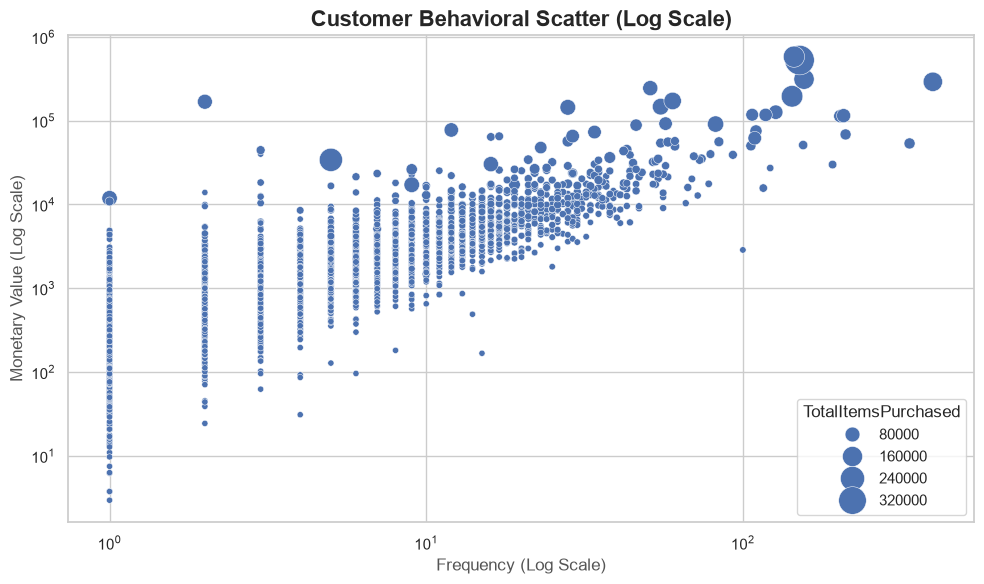

In [9]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=customer_df,
    x='Frequency',
    y='Monetary',
    size='TotalItemsPurchased',
    sizes=(20, 450),
)
plt.xscale('log')
plt.yscale('log')
plt.title('Customer Behavioral Scatter (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Frequency (Log Scale)',color="#555555")
plt.ylabel('Monetary Value (Log Scale)',color="#555555")
plt.tight_layout()

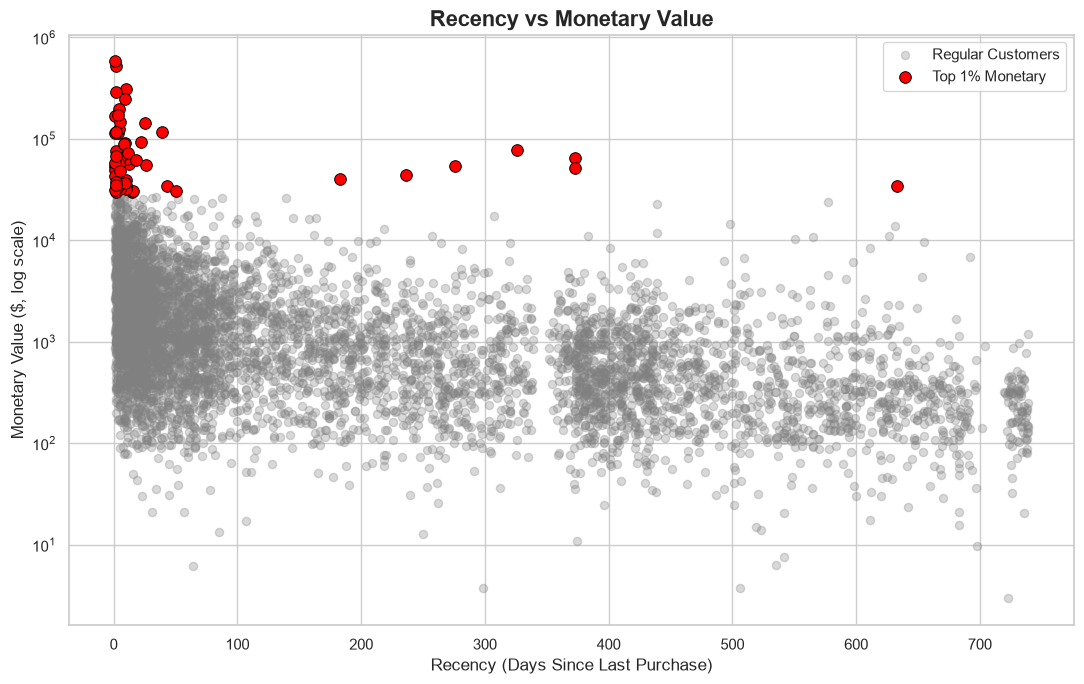

In [10]:
top_percentile = customer_df['Monetary'].quantile(0.99)
extreme_customers = customer_df[customer_df['Monetary'] >= top_percentile].copy()

plt.figure(figsize=(11, 7))

plt.scatter(
    customer_df['Recency'],
    customer_df['Monetary'],
    alpha=0.3,
    s=35,
    color='gray',
    label='Regular Customers'
)

plt.scatter(
    extreme_customers['Recency'],
    extreme_customers['Monetary'],
    s=70,
    marker='o',
    color='red',
    edgecolor='black',
    linewidth=0.7,
    label='Top 1% Monetary'
)

plt.yscale('log')
plt.title('Recency vs Monetary Value',fontsize=16,fontweight='bold')

plt.xlabel('Recency (Days Since Last Purchase)')
plt.ylabel('Monetary Value ($, log scale)')

plt.legend(loc='upper right')

plt.tight_layout()

Text(0.5, 1.0, 'Revenue Contribution of Top 1% Customers')

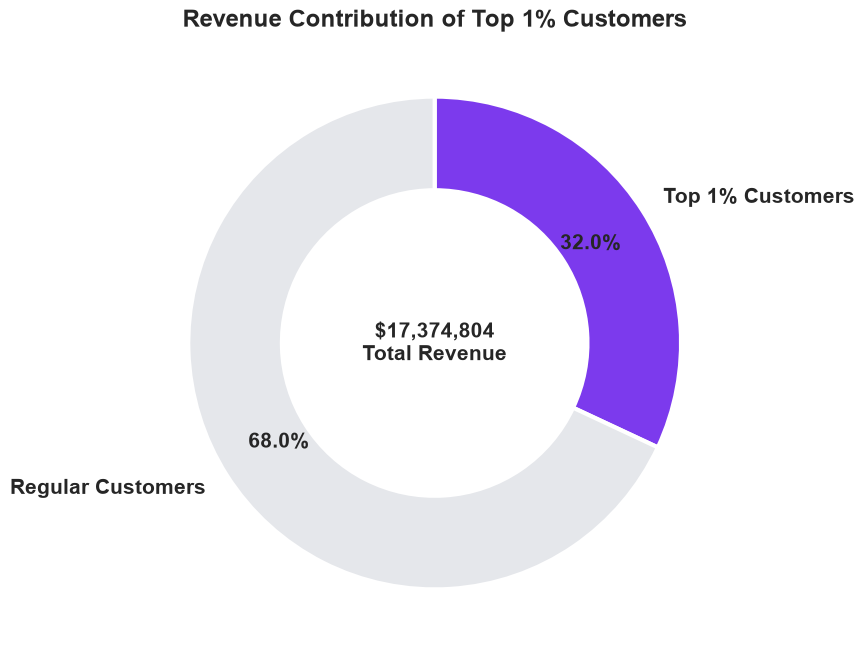

In [11]:
extreme_monetary = extreme_customers['Monetary'].sum()
regular_monetary = customer_df['Monetary'].sum() - extreme_monetary

fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    [extreme_monetary, regular_monetary],
    labels=['Top 1% Customers', 'Regular Customers'],
    colors=['#7C3AED', '#E5E7EB'],
    autopct='%1.1f%%',
    startangle=90,
    counterclock=False,
    pctdistance=0.75,
    wedgeprops={'width': 0.38,'edgecolor': 'white','linewidth': 3},
    textprops={'fontsize': 15,'fontweight': 'bold'}
)

ax.text(
    0, 0,
    f"${customer_df['Monetary'].sum():,.0f}\nTotal Revenue",
    ha='center',
    va='center',
    fontsize=15,
    fontweight='bold'
)

plt.title('Revenue Contribution of Top 1% Customers',fontsize=17, fontweight='bold',)

## Feature Analysis Conclusions & Next Steps

### Key Findings

The customer-level behavioral feature matrix contains **5,878 customers** represented by purchasing-value, frequency, product-diversity, temporal, and cancellation-related features.

The feature analysis identified several important characteristics that must be considered before clustering:

**1. Strong right-skewness in purchasing-volume features**

Several behavioral variables exhibit severe positive skewness and large differences between their median and maximum values. In particular, `Monetary`, `Frequency`, `TotalItemsPurchased`, `UniqueProducts`, `AverageOrderValue`, and `AverageItemsPerOrder` contain extreme high-value observations.

The `log1p` experiment substantially reduced skewness for these variables, making logarithmic transformation a strong candidate for preprocessing. However, transformations will not be applied indiscriminately to every feature.

`PurchaseRate`: Apply the selected power transformation to reduce severe right-skewness.

`Recency` and `CustomerLifetime` show relatively moderate skewness, while bounded proportions such as `WeekendPurchaseRatio` and `CancellationRate` have meaningful natural ranges between 0 and 1 and therefore do not automatically require logarithmic transformation.

---

**2. Extreme customers are an important part of the dataset**

IQR analysis identified substantial numbers of statistical outliers in purchasing-related variables, including approximately **10.77% of customers for `Monetary`** and **10.26% for `TotalItemsPurchased`**.

These observations should not be automatically removed. In a customer-segmentation problem, unusually high purchasing activity may represent commercially important customer behavior rather than erroneous data.

Therefore, the initial strategy will be to **preserve extreme customers** and reduce their numerical influence through suitable transformations and scaling. Outlier removal will only be considered when there is evidence that an observation represents invalid or corrupted behavior.

The high IQR-outlier percentage for `WeekendPurchaseRatio` also demonstrates that statistical outlier rules should not be interpreted as data-quality rules, particularly for bounded or zero-inflated behavioral variables.

---

**3. Several features are strongly correlated**

Spearman correlation analysis identified several feature pairs with \(|r| > 0.80\), including:

* `Monetary` and `Frequency`
* `Monetary` and `TotalItemsPurchased`
* `Frequency` and `TotalItemsPurchased`
* `Frequency` and `CustomerLifetime`
* `AverageOrderValue` and `AverageItemsPerOrder`

Correlation alone is not sufficient justification for removing behavioral features because correlated variables may still represent distinct customer concepts.

---

### Proposed Preprocessing Strategy

The feature analysis does **not** yet establish one universally optimal preprocessing method. Instead, the next stage will experimentally compare alternative representations.

Strongly right-skewed positive features will be considered for `log1p` transformation, while moderately skewed temporal variables and bounded ratio features will initially remain in their original form.

Because the dataset contains legitimate extreme purchasing behavior, both `StandardScaler` and `RobustScaler` will be evaluated rather than assuming that either scaler is automatically superior.

The candidate preprocessing representations will therefore include:

`Original Features → StandardScaler`

`Selected Log1p Transformations → StandardScaler`

`Selected Log1p Transformations → RobustScaler`

The best representation will ultimately be selected based on downstream clustering quality, stability, cluster-size balance, and business interpretability rather than distribution shape alone.


---

### Final Decision from Feature Analysis

The analysis supports the following modeling principle:

> **Preserve meaningful customer behavior, transform severe distributional extremes when justified, avoid redundant engineered signals, scale features before distance-based modeling, and allow clustering performance—not preprocessing assumptions—to determine the final representation.**

With these conclusions established, the project is ready to move from **feature understanding** to **preprocessing and PCA experimentation**.
